### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [ ]:
import pandas as pd
import numpy as np
from normalize_lfc_utils import *

In [ ]:
read_count = pd.read_excel("../../data/sgrna_lfc_data/brunello_data/brunello_A375_Sanson_2018.xlsx", sheet_name="A375_mod_tracr raw reads", skiprows = 1)
read_count = read_count.rename(columns={'sgRNA Sequence':'spacer'})
read_count

# filtered out sgRNA with less than 30 reads in T0
read_count = read_count[read_count['pDNA'] > 30]
read_count

,spacer,pDNA,RepA,RepB,RepC
0,AAAAAAAATCCGGACAATGG,247,358,1146,623
1,AAAAAAAGGATGGTGATCAA,119,1313,431,1078
2,AAAAAAATGACATTACTGCA,139,117,163,82
3,AAAAAAATGTCAGTCGAGTG,76,970,984,681
4,AAAAAACACAAGCAAGACCG,62,681,435,961
...,...,...,...,...,...
77436,TTTGTTTGGATTGCTTCAAG,226,207,94,165
77437,TTTTACCTTGTTCACATGGA,262,2406,2728,2472
77438,TTTTGACTCTAATCACCGGT,151,2654,2586,3860
77439,TTTTTAATACAAGGTAATCT,105,690,424,213


In [ ]:
# import library data
library_data = pd.read_csv("../../data/library_data/original_library/broadgpp-brunello-library-contents.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
display(library_data.shape)

(77441, 3)

In [ ]:
read_count = pd.merge(read_count, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="sgRNA")
read_count

,,,pDNA,RepA,RepB,RepC
sgRNA,spacer,gene,,,,
sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,327,1351,2055,1533
sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,120,1196,982,1472
sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,165,2287,2978,1812
sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,157,1721,2642,1696
sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,115,1690,1039,1524
...,...,...,...,...,...,...
sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,174,685,1581,1566
sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,88,70,265,98
sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,120,779,931,1107


In [ ]:
# we log transformed the raw read counts (log2(counts + 1))
log_transformed_read_count = np.log2(read_count + 1)
log_transformed_read_count

,,,pDNA,RepA,RepB,RepC
sgRNA,spacer,gene,,,,
sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,8.357552,10.400879,11.005625,10.583083
sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,6.918863,10.225207,9.941048,10.524542
sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,7.375039,11.159871,11.540612,10.824163
sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,7.303781,10.749869,11.367961,10.728771
sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,6.857981,10.723661,10.022368,10.574594
...,...,...,...,...,...,...
sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,7.451211,9.422065,10.627534,10.613789
sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,6.475733,6.149747,8.055282,6.629357
sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,6.918863,9.607330,9.864186,10.113742


In [ ]:
pDNA = log_transformed_read_count[['pDNA']]

# Compute log-fold change relative to T0
sgrna_lfc = log_transformed_read_count.drop(columns=['pDNA']).subtract(pDNA.values, axis = 0)
sgrna_lfc

,,,RepA,RepB,RepC
sgRNA,spacer,gene,,,
sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,2.043327,2.648073,2.225531
sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,3.306344,3.022184,3.605678
sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,3.784832,4.165573,3.449124
sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,3.446089,4.064180,3.424990
sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,3.865680,3.164387,3.716613
...,...,...,...,...,...
sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,1.970854,3.176323,3.162578
sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,-0.325986,1.579549,0.153623
sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,2.688467,2.945323,3.194879


In [ ]:
# Center LFCs using non-essential guides
non_essential_mask = ~log_transformed_read_count.index.get_level_values(2).isin(["Non-Targeting Control"])
median_non_essential = sgrna_lfc[non_essential_mask].median(axis=0)

median_non_essential

RepA    2.750464
RepB    2.868659
RepC    2.695057
dtype: float64

In [ ]:
# Subtract median of non-essential guides for each sample (normalized sgrna LFC)
sgrna_lfc_normalized = sgrna_lfc - median_non_essential
sgrna_lfc_normalized

,,,RepA,RepB,RepC
sgRNA,spacer,gene,,,
sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,-0.707136,-0.220586,-0.469526
sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,0.555880,0.153525,0.910622
sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,1.034368,1.296914,0.754067
sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,0.695625,1.195521,0.729934
sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,1.115216,0.295728,1.021556
...,...,...,...,...,...
sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,-0.779610,0.307664,0.467522
sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,-3.076450,-1.289110,-2.541433
sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,-0.061997,0.076664,0.499822


In [ ]:
# scaled sgRNA log fold change by centering around the median LFC of guides targeting essential genes
norm_sgrna_lfc_scaled, list_common_essential = scale_essential(sgrna_lfc_normalized, '../../data/sgrna_lfc_data/constitutive_core_essential_hart_2014.csv')
norm_sgrna_lfc_scaled

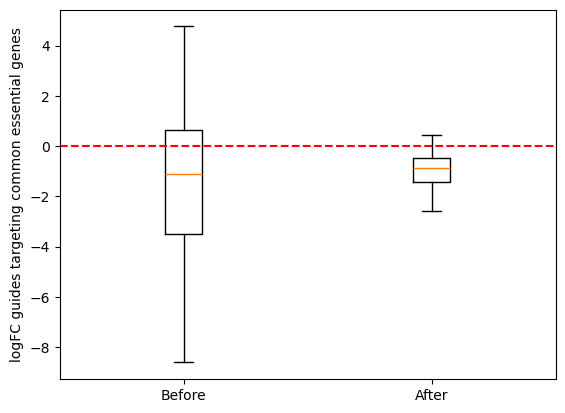

In [ ]:
# check whether the normalization works (the median of lfc data should be around 0)
sanity_check_scale_essential(sgrna_lfc, norm_sgrna_lfc_scaled, list_common_essential)

In [ ]:
# averaged sgRNA LFC across replicates
lfc_norm_scaled_avg = mean_row(norm_sgrna_lfc_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,-0.105763
1,sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,0.122626
2,sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,0.233542
3,sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,0.198400
4,sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,0.184125
...,...,...,...,...
74919,sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,-0.000335
74920,sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,-0.522817
74921,sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,0.038944
74922,sgZZZ3_3,GCAGAGTACCCGAGAATCAT,ZZZ3,0.001109


In [ ]:
lfc_norm_scaled_avg.to_csv("../../data/sgrna_lfc_data/output_normalized/brunello_a375_normalized_lfc.csv", index=False)